In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

se = pl.read_parquet('../data/processed/core_stop_events.parquet')
print(f'Total stop events: {len(se):,}')
print(f'Columns: {se.columns}')

Total stop events: 994,117
Columns: ['fzg_id', 'drop_row_idx', 'arrival_time', 'departure_time', 'linie', 'fahrt_id', 'ort_nr_start', 'stop_index', 'stop_status', 'scheduled_arrival_time', 'delay_calculated_sec', 'delay_recorded_sec', 'dwell_time', 'travel_time', 'besetztgrad', 'is_peak_hour', 'is_workday', 'has_traffic_signal']


## Step 1 — Stop status 分布

=== Stop status 整体分布 ===
shape: (3, 3)
┌─────────────┬────────┬───────┐
│ stop_status ┆ count  ┆ pct   │
│ ---         ┆ ---    ┆ ---   │
│ str         ┆ u32    ┆ f64   │
╞═════════════╪════════╪═══════╡
│ normal      ┆ 787793 ┆ 79.25 │
│ no_door     ┆ 203944 ┆ 20.52 │
│ multi_door  ┆ 2380   ┆ 0.24  │
└─────────────┴────────┴───────┘


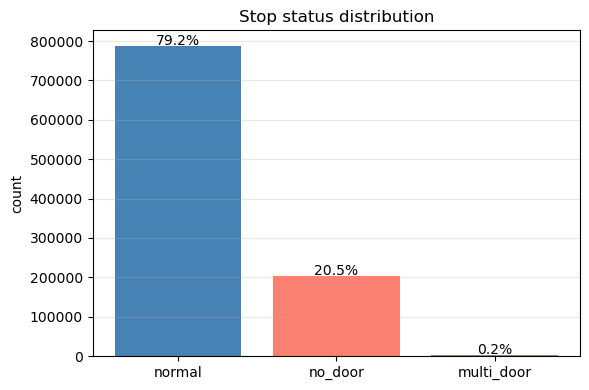

In [2]:
status_dist = (
    se.group_by('stop_status')
    .agg(pl.len().alias('count'))
    .with_columns((pl.col('count') / len(se) * 100).round(2).alias('pct'))
    .sort('count', descending=True)
)
print('=== Stop status 整体分布 ===')
print(status_dist)

fig, ax = plt.subplots(figsize=(6, 4))
colors = {'normal': 'steelblue', 'no_door': 'salmon', 'multi_door': 'mediumseagreen'}
labels = status_dist['stop_status'].to_list()
counts = status_dist['count'].to_list()
ax.bar(labels, counts, color=[colors.get(l, 'gray') for l in labels])
for i, (l, c) in enumerate(zip(labels, counts)):
    ax.text(i, c + 2000, f'{c/len(se)*100:.1f}%', ha='center', fontsize=10)
ax.set_ylabel('count')
ax.set_title('Stop status distribution')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 2 — Dwell time 分布（normal + multi_door）

In [3]:
with_door = se.filter(pl.col('stop_status') != 'no_door')
total_with_door = len(with_door)

n_negative = (with_door['dwell_time'] < 0).sum()
n_zero     = (with_door['dwell_time'] == 0).sum()
n_positive = (with_door['dwell_time'] > 0).sum()

print(f'normal + multi_door 总计: {total_with_door:,}')
print()
print(f'dwell_time < 0  : {n_negative:>8,}  ({n_negative/total_with_door*100:.2f}%)')
print(f'dwell_time == 0 : {n_zero:>8,}  ({n_zero/total_with_door*100:.2f}%)  ← rescue 后残余（真实数据缺失）')
print(f'dwell_time > 0  : {n_positive:>8,}  ({n_positive/total_with_door*100:.2f}%)  ← 可信')
print()

pos = with_door.filter(pl.col('dwell_time') > 0)['dwell_time'].to_numpy()
print('=== dwell_time > 0 的分布（秒）===')
for p in [5, 25, 50, 75, 90, 95, 99]:
    print(f'  p{p:<3d}: {np.percentile(pos, p):>7.1f} s')
print(f'  mean: {pos.mean():>7.1f} s')

normal + multi_door 总计: 790,173

dwell_time < 0  :        0  (0.00%)
dwell_time == 0 :   72,344  (9.16%)  ← rescue 后残余（真实数据缺失）
dwell_time > 0  :  717,829  (90.84%)  ← 可信

=== dwell_time > 0 的分布（秒）===
  p5  :    10.9 s
  p25 :    16.0 s
  p50 :    20.0 s
  p75 :    28.0 s
  p90 :    48.7 s
  p95 :    73.0 s
  p99 :   593.0 s
  mean:    44.9 s


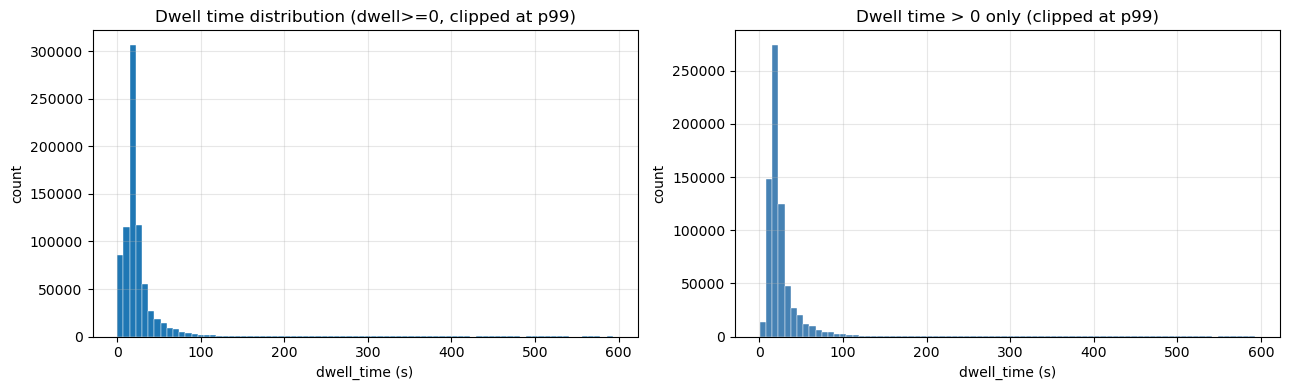

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 左：dwell_time 分布概览（含 0）
dt_vals = with_door['dwell_time'].to_numpy().astype(float)
clip = np.percentile(dt_vals[dt_vals > 0], 99)
plot_vals = dt_vals[(dt_vals >= 0) & (dt_vals <= clip)]
axes[0].hist(plot_vals, bins=80, edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('dwell_time (s)')
axes[0].set_ylabel('count')
axes[0].set_title('Dwell time distribution (dwell>=0, clipped at p99)')
axes[0].grid(alpha=0.3)

# 右：仅 dwell_time > 0
clip2 = np.percentile(pos, 99)
axes[1].hist(pos[pos <= clip2], bins=80, edgecolor='white', linewidth=0.3, color='steelblue')
axes[1].set_xlabel('dwell_time (s)')
axes[1].set_ylabel('count')
axes[1].set_title('Dwell time > 0 only (clipped at p99)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 3 — 按路线看 dwell_time=0 比例

In [5]:
linie_dwell = (
    with_door
    .group_by('linie')
    .agg([
        pl.len().alias('total'),
        (pl.col('dwell_time') == 0).sum().alias('n_zero'),
        (pl.col('dwell_time') > 0).sum().alias('n_positive'),
        pl.col('dwell_time').filter(pl.col('dwell_time') > 0).median().alias('median_pos'),
    ])
    .with_columns(
        (pl.col('n_zero') / pl.col('total') * 100).round(1).alias('pct_zero')
    )
    .sort('pct_zero', descending=True)
)

print('=== 各路线 dwell_time=0 比例 ===')
print(linie_dwell.to_pandas().to_string(index=False))

=== 各路线 dwell_time=0 比例 ===
 linie  total  n_zero  n_positive  median_pos  pct_zero
    92   1831     530        1301   14.004524      28.9
    77   5108    1213        3895   18.011785      23.7
    84   2292     426        1866   14.018760      18.6
    78   5287     878        4409   16.995068      16.6
    74   1361     224        1137   28.006627      16.5
    47   5424     780        4644   20.002775      14.4
    88   3337     476        2861   17.040850      14.3
   104  13792    1894       11898   19.005430      13.7
    81   2866     391        2475   18.005139      13.6
    72   3337     451        2886   16.999472      13.5
    90   9447    1257        8190   17.999660      13.3
    79   1513     200        1313   15.985842      13.2
   166   2398     317        2081   15.019326      13.2
    87   7678     944        6734   17.016678      12.3
    68  33570    4099       29471   19.036832      12.2
   108   6996     792        6204   23.006992      11.3
    73   1677     18

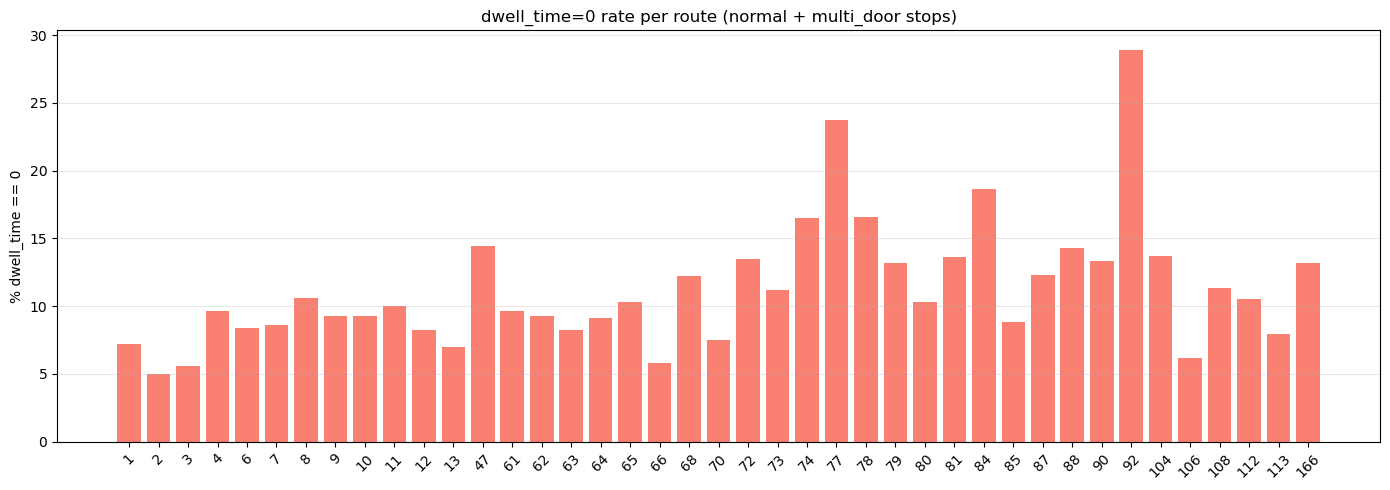

In [6]:
df_plot = linie_dwell.sort('linie').to_pandas()

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(df_plot))
ax.bar(x, df_plot['pct_zero'], color='salmon', label='dwell=0 (%)')
ax.set_xticks(list(x))
ax.set_xticklabels(df_plot['linie'].astype(str), rotation=45)
ax.set_ylabel('% dwell_time == 0')
ax.set_title('dwell_time=0 rate per route (normal + multi_door stops)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4 — 残余 dwell=0 分析

rescue 层已对 186,808 条 dwell=0 事件做了扩展搜索，修复了 142,390 条（76%）。
剩余 64,037 条（6.4%）在 `(prev_drop_idx, next_drop_idx)` 整个范围内仍找不到完整门事件，属于真实数据缺失。

对残余事件再次拆解原因：
- **Case 1**：arrival ≠ drop_time（找到了开门），但整个两站间隔内没有关门
- **Case 2**：arrival == drop_time（连开门都没找到），整个两站间隔内门始终关闭

In [7]:
RAW = '../data/regular_linie_week.csv'

raw_ts = (
    pl.read_csv(RAW, columns=['tst_iso', 'fzg_id'])
    .with_columns(pl.col('tst_iso').str.to_datetime(format='%Y-%m-%dT%H:%M:%S%.f%z'))
    .sort(['fzg_id', 'tst_iso'])
    .with_columns(pl.int_range(pl.len()).over('fzg_id').alias('row_idx'))
    .rename({'tst_iso': 'drop_time'})
)

dwell0 = (
    with_door
    .filter(pl.col('dwell_time') == 0)
    .join(
        raw_ts.select(['fzg_id', 'row_idx', 'drop_time']),
        left_on  = ['fzg_id', 'drop_row_idx'],
        right_on = ['fzg_id', 'row_idx'],
        how      = 'left',
    )
    .with_columns(
        pl.when(pl.col('arrival_time') == pl.col('drop_time'))
          .then(pl.lit('Case2: 未找到开门 (arrival=drop_time)'))
          .otherwise(pl.lit('Case1: 找到开门但未找到关门'))
          .alias('zero_reason')
    )
)

reason_dist = (
    dwell0.group_by('zero_reason')
    .agg(pl.len().alias('count'))
    .with_columns((pl.col('count') / len(dwell0) * 100).round(2).alias('pct'))
    .sort('count', descending=True)
)
print(f'dwell=0 总计: {len(dwell0):,}')
print()
print(reason_dist)

dwell=0 总计: 72,344

shape: (2, 3)
┌─────────────────────────────────┬───────┬───────┐
│ zero_reason                     ┆ count ┆ pct   │
│ ---                             ┆ ---   ┆ ---   │
│ str                             ┆ u32   ┆ f64   │
╞═════════════════════════════════╪═══════╪═══════╡
│ Case1: 找到开门但未找到关门     ┆ 40971 ┆ 56.63 │
│ Case2: 未找到开门               ┆ 31373 ┆ 43.37 │
│ (arrival=drop_tim…              ┆       ┆       │
└─────────────────────────────────┴───────┴───────┘


In [8]:
no_door = se.filter(pl.col('stop_status') == 'no_door')
print('=== no_door sentinel 验证 ===')
print(f'no_door dwell_time 唯一值: {no_door["dwell_time"].unique().to_list()}')
print()

total      = len(se)
n_no_door  = len(no_door)
n_dwell0   = int(n_zero)
n_reliable = int(n_positive)

print('=== 最终问题规模（当前）===')
print(f'总 stop events            : {total:>8,}   100%')
print(f'dwell > 0（可信）         : {n_reliable:>8,}  {n_reliable/total*100:.1f}%')
print(f'no_door（dwell=-1 哨兵）  : {n_no_door:>8,}  {n_no_door/total*100:.1f}%  无门事件，不可计算')
print(f'dwell = 0（残余，数据缺失）: {n_dwell0:>8,}  {n_dwell0/total*100:.1f}%  建议建模时过滤')
print()
print('=== 四阶段对比 ===')
print(f'{"阶段":<28} {"dwell>0":>8} {"dwell=0":>8} {"no_door":>8}')
print('-' * 56)
print(f'{"旧代码（修复前）":<25} {"27.8%":>8} {"53.8%":>8} {"17.5%":>8}')
print(f'{"detector arrival/departure 修复":<22} {"65.6%":>8} {"16.9%":>8} {"17.5%":>8}')
print(f'{"+ rescue 补救层":<25} {"75.8%":>8} {"6.4%":>8} {"17.8%":>8}')
print(f'{"+ 窗口边界裁剪（当前）":<23} {f"{n_reliable/total*100:.1f}%":>8} {f"{n_dwell0/total*100:.1f}%":>8} {f"{n_no_door/total*100:.1f}%":>8}')

=== no_door sentinel 验证 ===
no_door dwell_time 唯一值: [-1.0]

=== 最终问题规模（当前）===
总 stop events            :  994,117   100%
dwell > 0（可信）         :  717,829  72.2%
no_door（dwell=-1 哨兵）  :  203,944  20.5%  无门事件，不可计算
dwell = 0（残余，数据缺失）:   72,344  7.3%  建议建模时过滤

=== 四阶段对比 ===
阶段                            dwell>0  dwell=0  no_door
--------------------------------------------------------
旧代码（修复前）                     27.8%    53.8%    17.5%
detector arrival/departure 修复    65.6%    16.9%    17.5%
+ rescue 补救层                 75.8%     6.4%    17.8%
+ 窗口边界裁剪（当前）               72.2%     7.3%    20.5%


## Step 6 — 残余 dwell=0 示例（5 条）

展示 rescue 后仍为 dwell=0 的 normal/multi_door 停站，附 prev_drop 到 next_drop 之间的完整原始数据，便于逐行检查门信号。

In [9]:
RAW = '../data/regular_linie_week.csv'

raw_full = (
    pl.read_csv(RAW, columns=['tst_iso', 'fzg_id', 'distanz', 'tuerkriterium'])
    .with_columns(pl.col('tst_iso').str.to_datetime(format='%Y-%m-%dT%H:%M:%S%.f%z'))
    .sort(['fzg_id', 'tst_iso'])
    .with_columns([
        pl.int_range(pl.len()).over('fzg_id').alias('row_idx'),
        pl.col('distanz').diff().over('fzg_id').alias('delta'),
    ])
)

samples = (
    se.filter(
        (pl.col('stop_status') != 'no_door') &
        (pl.col('dwell_time') == 0)
    )
    .sample(5, seed=42)
)

# prev/next drop 基于 parquet（仅匹配的停站）
se_sorted = se.sort(['fzg_id', 'drop_row_idx'])

for row in samples.iter_rows(named=True):
    vid      = row['fzg_id']
    drop_idx = row['drop_row_idx']

    vdrops   = se_sorted.filter(pl.col('fzg_id') == vid)['drop_row_idx'].to_list()
    pos      = vdrops.index(drop_idx)
    prev_drop = vdrops[pos - 1] if pos > 0          else None
    next_drop = vdrops[pos + 1] if pos < len(vdrops) - 1 else None

    lo = prev_drop if prev_drop is not None else max(0, drop_idx - 15)
    hi = next_drop if next_drop is not None else drop_idx + 15

    win = (
        raw_full.filter(pl.col('fzg_id') == vid)
        .filter(pl.col('row_idx').is_between(lo, hi))
        .sort('row_idx')
    )

    print('fzg=%-6d  drop=%-6d  linie=%-4d  status=%s' % (vid, drop_idx, row['linie'], row['stop_status']))
    print('  prev_drop=%-6s  next_drop=%-6s' % (prev_drop, next_drop))
    print('  arrival_time=%s' % row['arrival_time'])
    print('  %8s  %8s  %8s  %5s  note' % ('row_idx', 'distanz', 'delta', 'door'))
    for r in win.iter_rows(named=True):
        note = ''
        if r['row_idx'] == drop_idx:   note = '<-- DROP'
        if r['row_idx'] == prev_drop:  note = '<-- prev drop'
        if r['row_idx'] == next_drop:  note = '<-- next drop'
        print('  %8d  %8s  %8s  %5s  %s' % (
            r['row_idx'], str(r['distanz']), str(r['delta']),
            str(r['tuerkriterium']), note
        ))
    print()

fzg=2164    drop=3422    linie=61    status=normal
  prev_drop=3415    next_drop=3425  
  arrival_time=2025-07-28 22:55:32.582300+00:00
   row_idx   distanz     delta   door  note
      3415        25      -285  False  <-- prev drop
      3416       101        76  False  
      3417       185        84  False  
      3418       295       110  False  
      3419       312        17  False  
      3420       436       124  False  
      3421       554       118  False  
      3422        42      -512  False  <-- DROP
      3423       618       576   True  
      3424       618         0   True  
      3425        15      -603  False  <-- next drop

fzg=1152    drop=3697    linie=84    status=normal
  prev_drop=3585    next_drop=3709  
  arrival_time=2025-07-29 20:49:21.078857+00:00
   row_idx   distanz     delta   door  note
      3585        15      -704  False  <-- prev drop
      3586         0       -15   True  
      3587         0         0   True  
      3588         0         0  

## Step 7 — dwell=-1（no_door）示例（5 条）

展示 no_door 停站在 prev_drop 到 next_drop 之间的原始门信号，确认确实无门事件。

In [10]:
samples_nodoor = (
    se.filter(pl.col('dwell_time') == -1)
    .sample(5, seed=7)
)

for row in samples_nodoor.iter_rows(named=True):
    vid      = row['fzg_id']
    drop_idx = row['drop_row_idx']

    vdrops    = se_sorted.filter(pl.col('fzg_id') == vid)['drop_row_idx'].to_list()
    pos       = vdrops.index(drop_idx)
    prev_drop = vdrops[pos - 1] if pos > 0              else None
    next_drop = vdrops[pos + 1] if pos < len(vdrops) - 1 else None

    lo = prev_drop if prev_drop is not None else max(0, drop_idx - 15)
    hi = next_drop if next_drop is not None else drop_idx + 15

    win = (
        raw_full.filter(pl.col('fzg_id') == vid)
        .filter(pl.col('row_idx').is_between(lo, hi))
        .sort('row_idx')
    )

    print('fzg=%-6d  drop=%-6d  linie=%-4d  status=%s  dwell=%s' % (
        vid, drop_idx, row['linie'], row['stop_status'], row['dwell_time']))
    print('  prev_drop=%-6s  next_drop=%-6s' % (prev_drop, next_drop))
    print('  %8s  %8s  %8s  %5s  note' % ('row_idx', 'distanz', 'delta', 'door'))
    for r in win.iter_rows(named=True):
        note = ''
        if r['row_idx'] == drop_idx:   note = '<-- DROP'
        if r['row_idx'] == prev_drop:  note = '<-- prev drop'
        if r['row_idx'] == next_drop:  note = '<-- next drop'
        print('  %8d  %8s  %8s  %5s  %s' % (
            r['row_idx'], str(r['distanz']), str(r['delta']),
            str(r['tuerkriterium']), note
        ))
    print()

fzg=806     drop=25070   linie=11    status=no_door  dwell=-1.0
  prev_drop=25061   next_drop=25077 
   row_idx   distanz     delta   door  note
     25061        42      -648  False  <-- prev drop
     25062        42         0  False  
     25063        73        31  False  
     25064       102        29  False  
     25065       217       115  False  
     25066       296        79  False  
     25067       298         2  False  
     25068       298         0  False  
     25069       427       129  False  
     25070        54      -373  False  <-- DROP
     25071        54         0  False  
     25072       216       162  False  
     25073       227        11  False  
     25074       366       139  False  
     25075       413        47  False  
     25076       512        99  False  
     25077        66      -446  False  <-- next drop

fzg=1140    drop=6942    linie=88    status=no_door  dwell=-1.0
  prev_drop=6935    next_drop=6945  
   row_idx   distanz     delta   door  